In [1]:
# Plot baseline mortality for years 2000, 2010 and 2020

In [15]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import FuncFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.utils import autosize_figure, land_filter, create_global_country_map

In [3]:
# === Path config ===
BMR_DIR = "/glade/work/awells/air_quality/BMR/"
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/mortality/"

In [32]:
# === Health variables ===
# COPD (chronic obstructive pulonary disease)
# LRI (lower respiratory infection)
# IHD (ischemic heart disease)
# DM2 (type 2 diabetes)
# LC (tracheal, bronchus, and lung cancer)
# Stroke
health_vars = ["COPD", "LRI", "IHD", "DM", "LC", "Stroke"]

In [ ]:
def plot_log_mortality(da, health_VAR, year, SAVE_DIR):
    # Handle zero or negative values
    da_safe = da.where(da > 0)

    # Define discrete log-spaced levels
    vmax = da_safe.max().values

    # Define boundaries: round to nearest powers of 10 for readability
    min_exp = 0  # set lower bound to 1 (e^0)
    max_exp = int(np.ceil(np.log10(vmax)))
    boundaries = np.logspace(min_exp, max_exp, max_exp - min_exp + 1)

    # Create discrete norm
    norm = BoundaryNorm(boundaries, ncolors=plt.get_cmap('viridis').N)

    # Create figure and layout
    fig = plt.figure(figsize=autosize_figure(1, 1))
    gs = GridSpec(2, 1, height_ratios=[15, 1])

    projection = ccrs.Robinson()
    crs = ccrs.PlateCarree()

    country_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none')

    # Plot map
    ax = fig.add_subplot(gs[0, 0], projection=projection)
    cb = da_safe.plot(
        transform=crs,
        add_colorbar=False,
        cmap='viridis',
        norm=norm,
        subplot_kws={'projection': projection}
    )
    ax.coastlines(resolution="50m", linewidth=0.75)
    ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
    plt.title(f"{health_VAR} Mortality in {year}", fontsize=16)

    # Formatter: display as plain integers
    def integer_formatter(x, pos):
        return f"{int(x)}" if x >= 1 else f"{x:.1g}"

    formatter = FuncFormatter(integer_formatter)

    # Colorbar
    cax = fig.add_subplot(gs[1, 0])
    col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal',
                           boundaries=boundaries, ticks=boundaries)
    col_bar.set_label(f"Mortality due to {health_VAR}", fontsize=13)
    col_bar.ax.xaxis.set_major_formatter(formatter)

    plt.tight_layout()

    out_file = f"Mortality_mean_{health_VAR}_{year}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)
    return

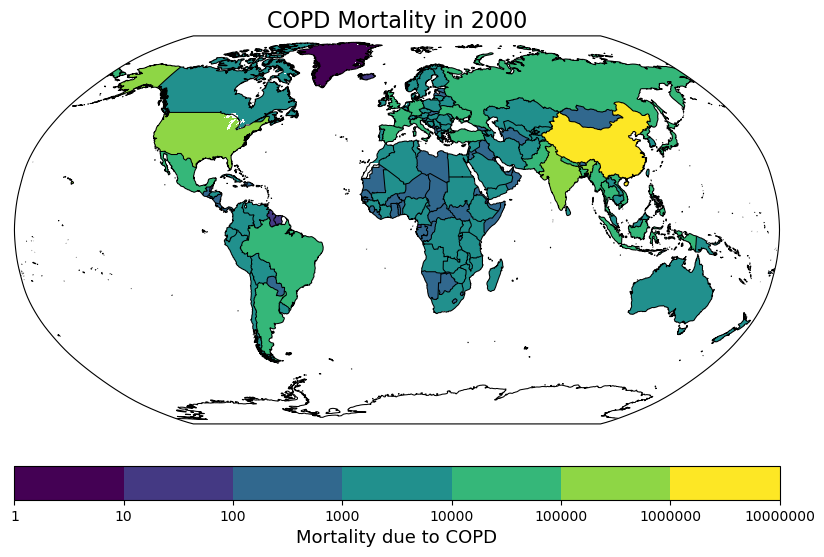

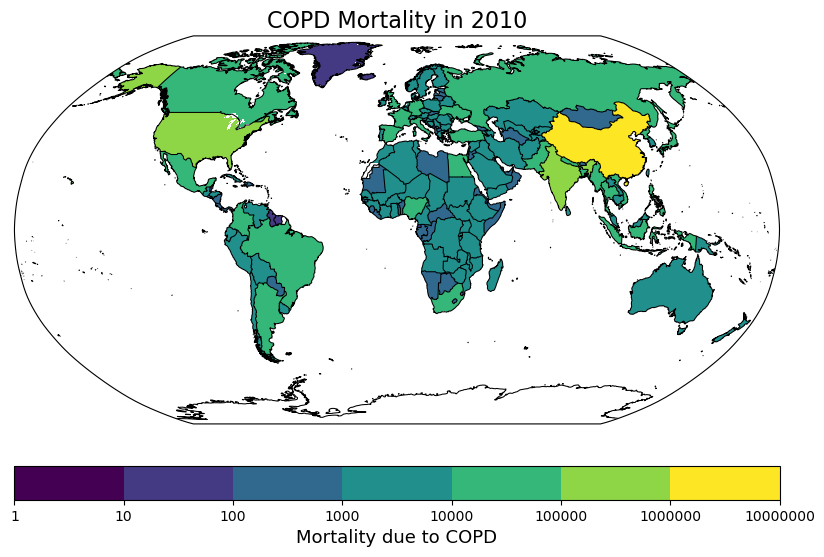

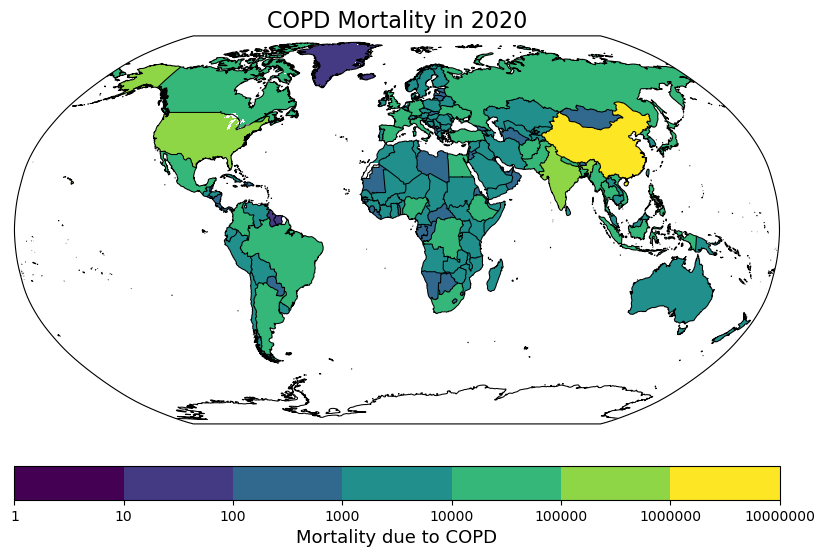

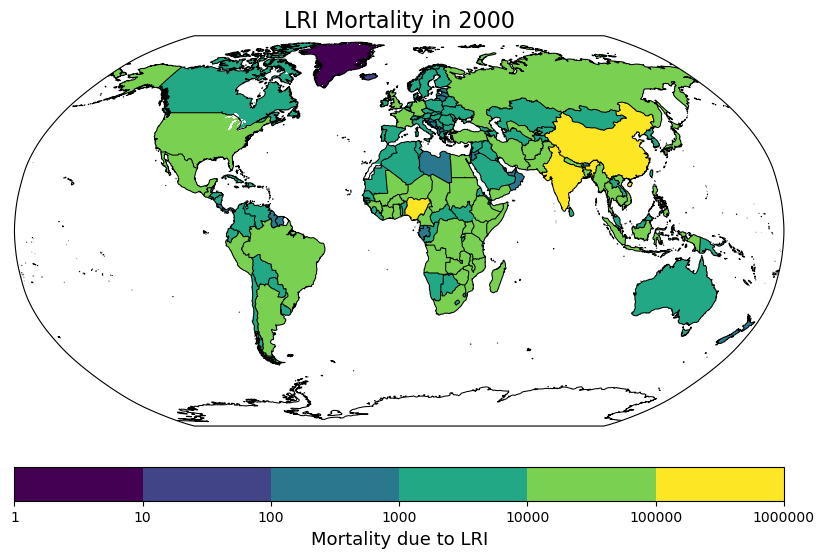

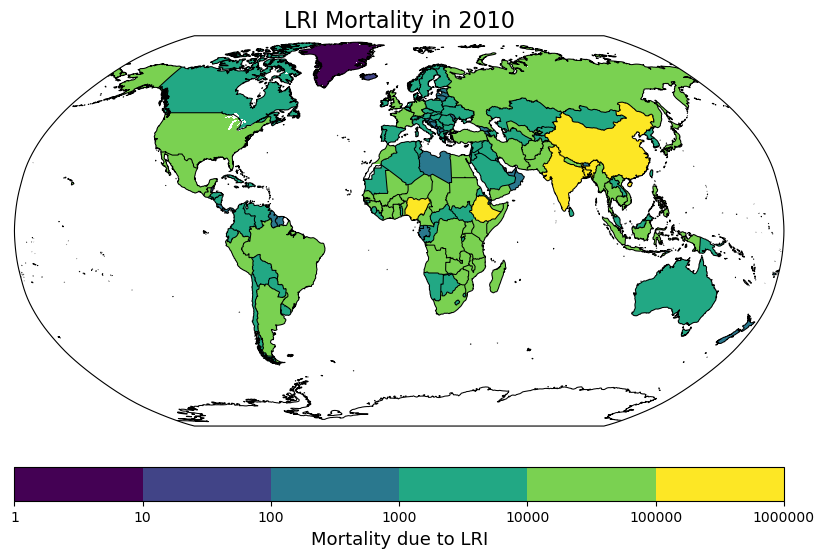

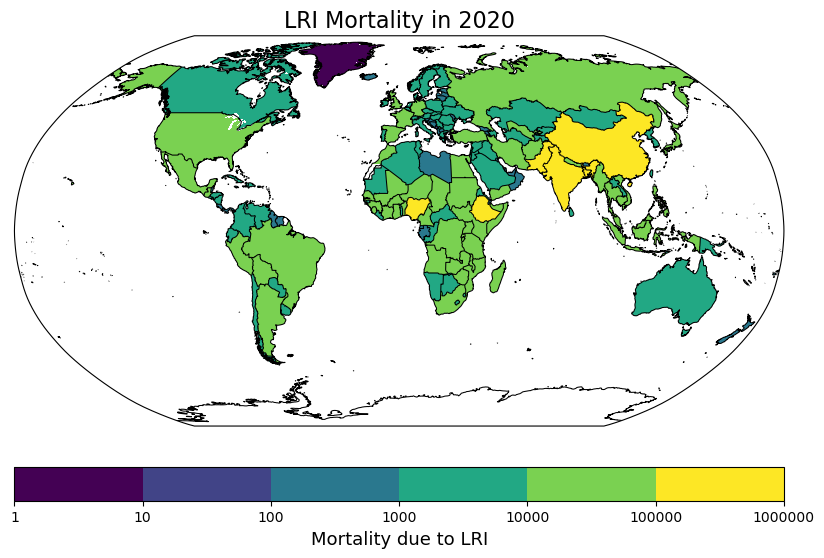

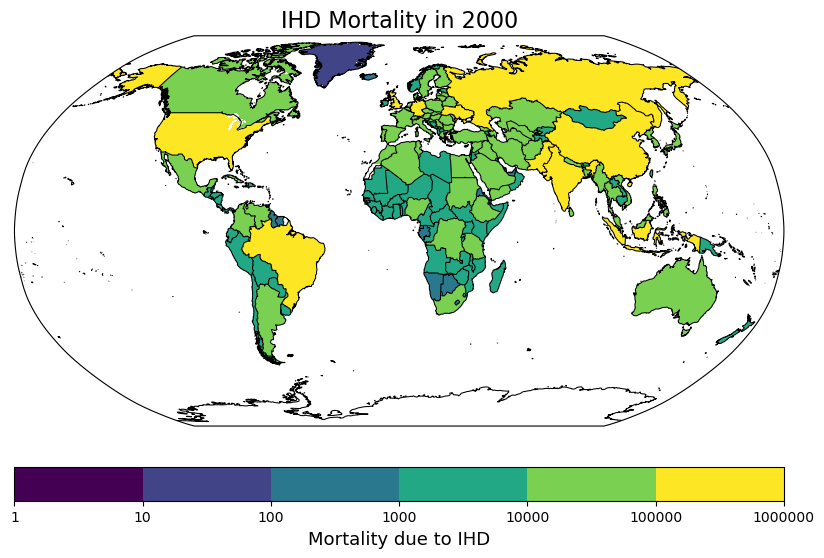

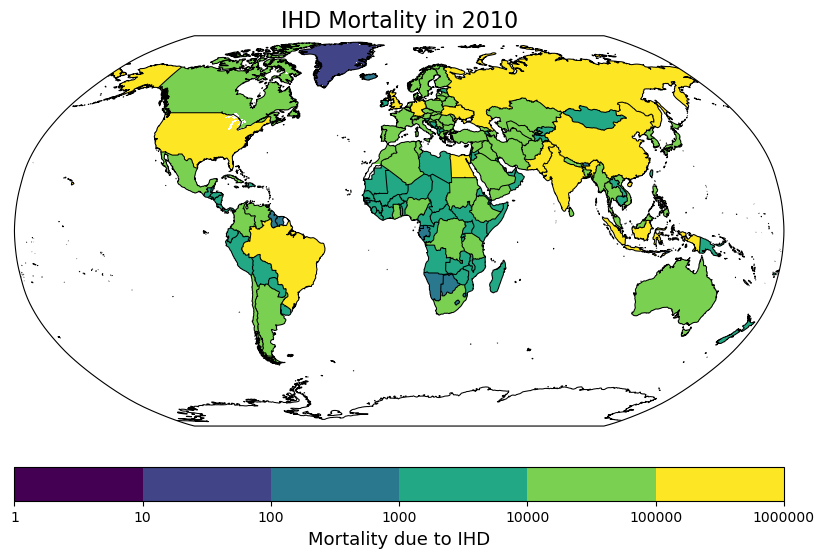

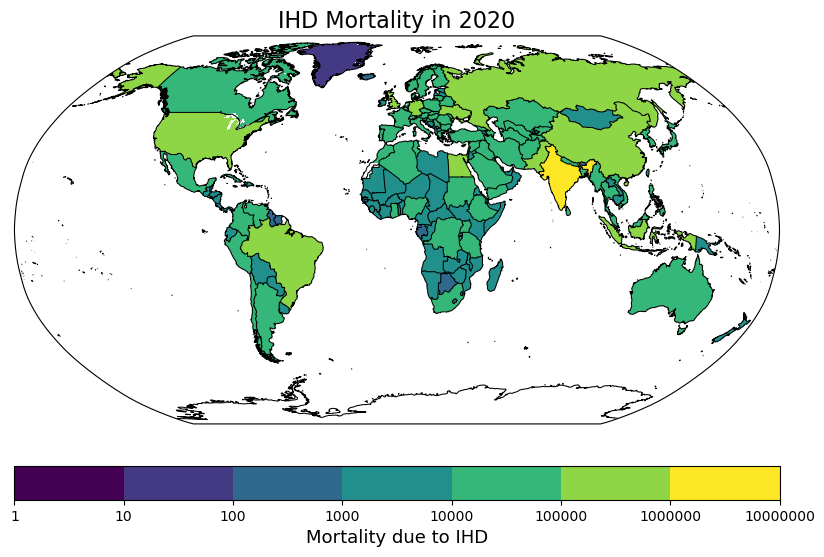

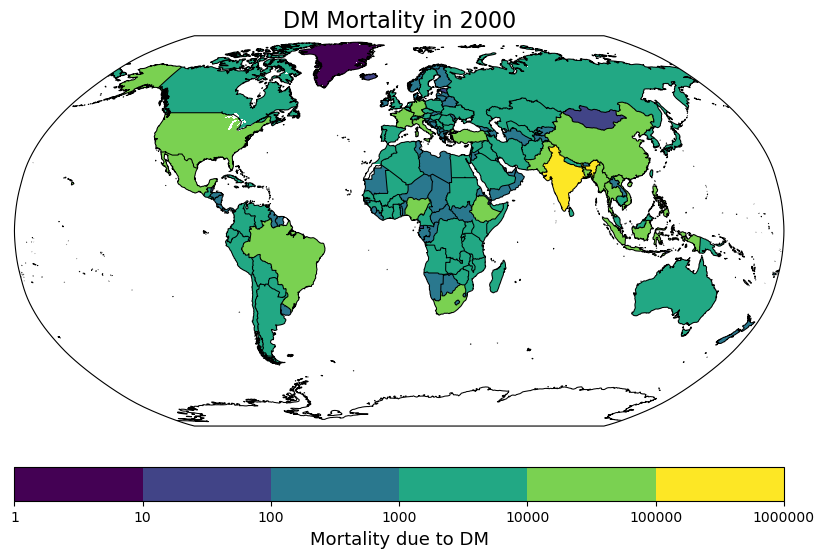

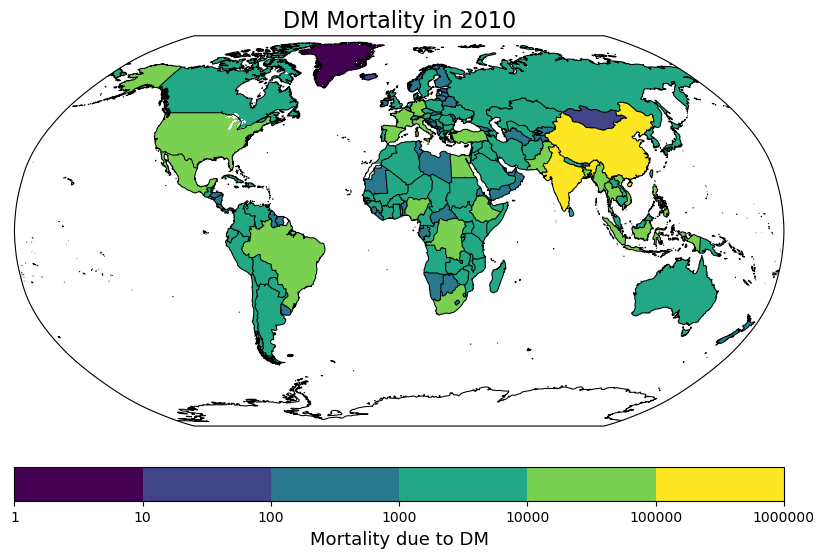

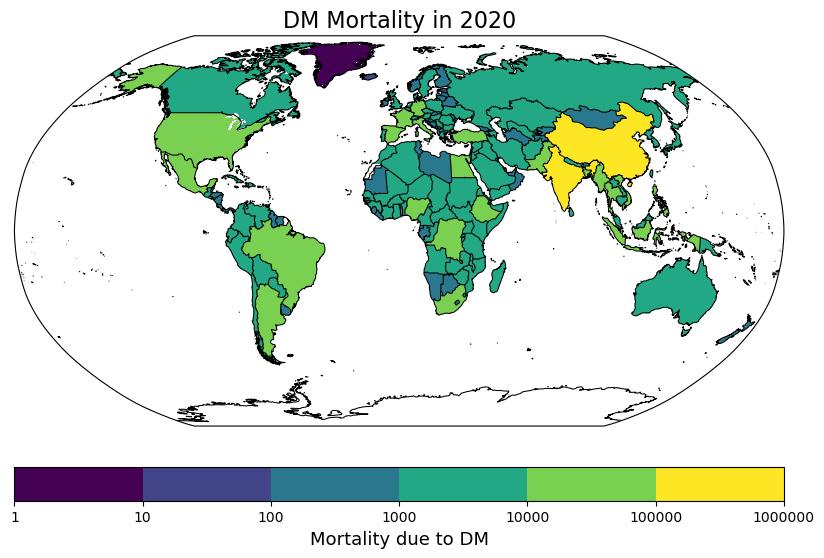

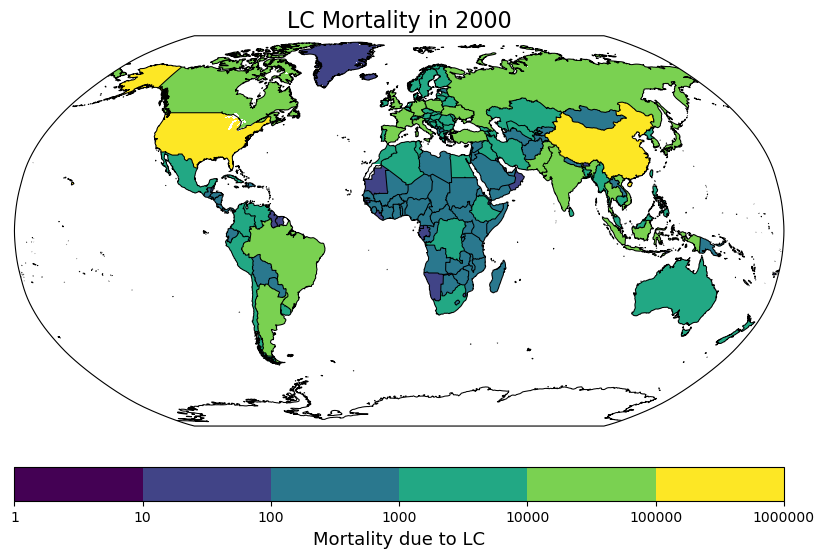

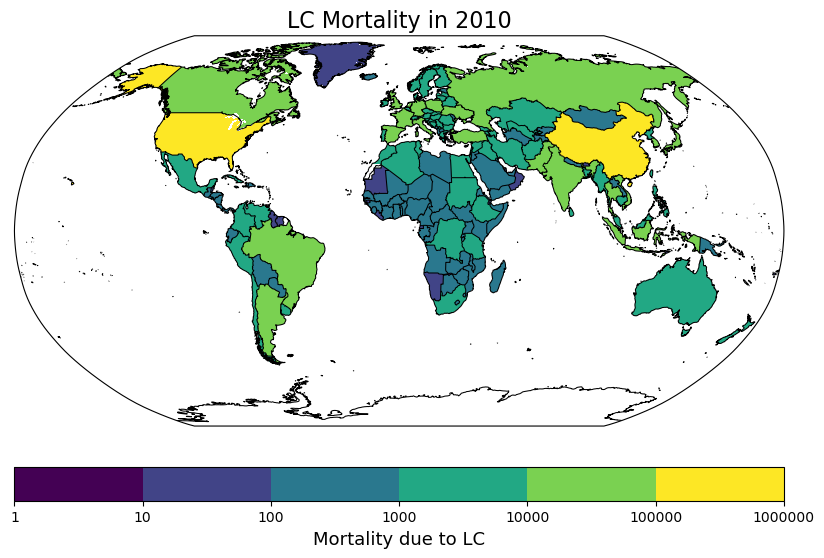

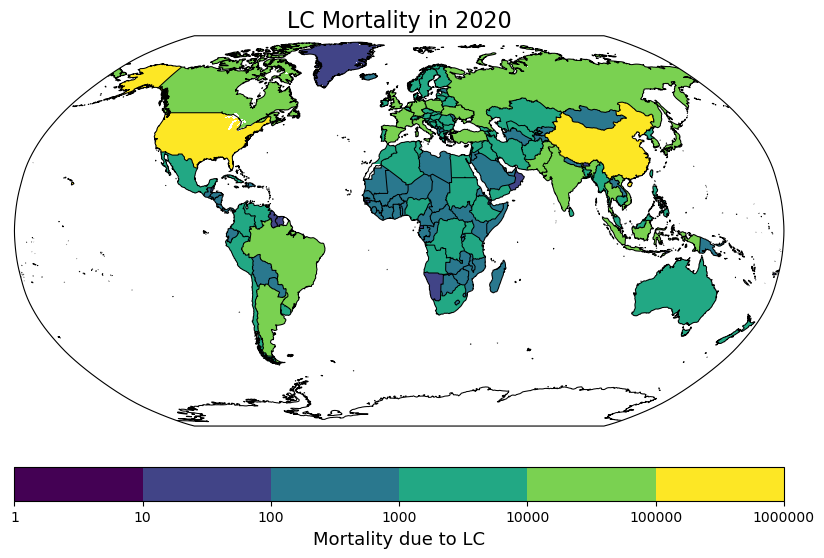

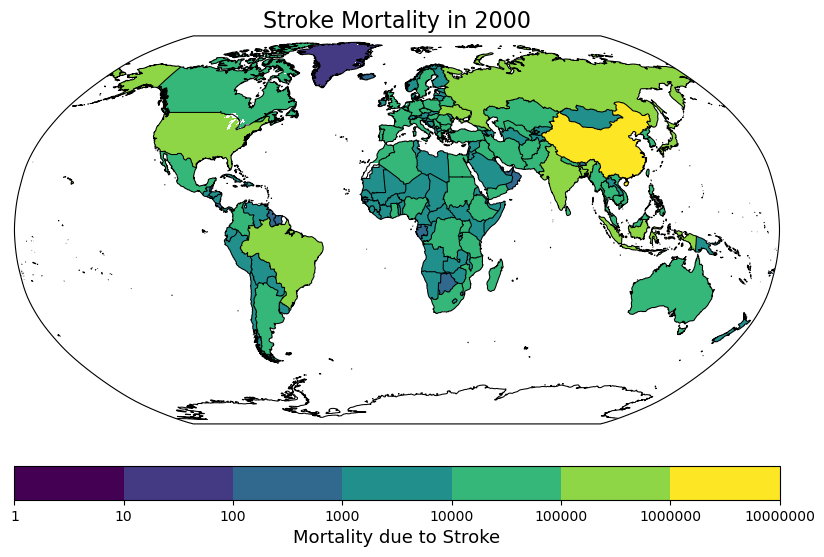

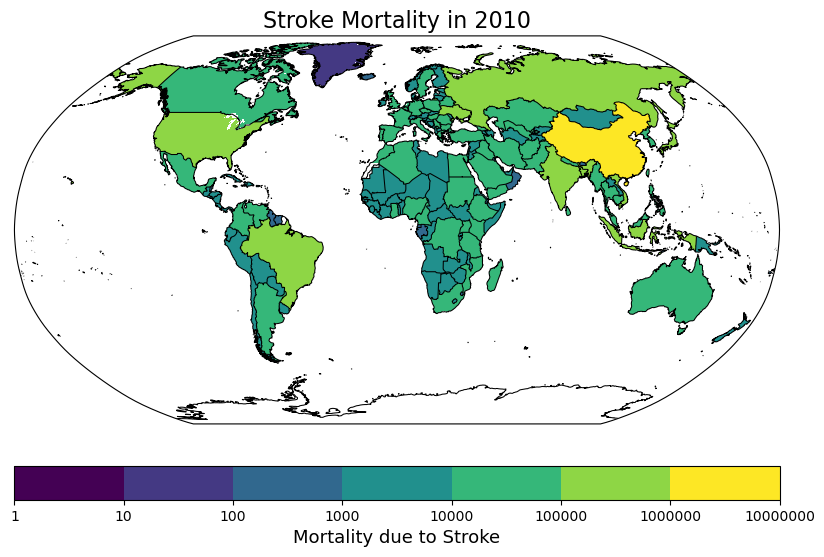

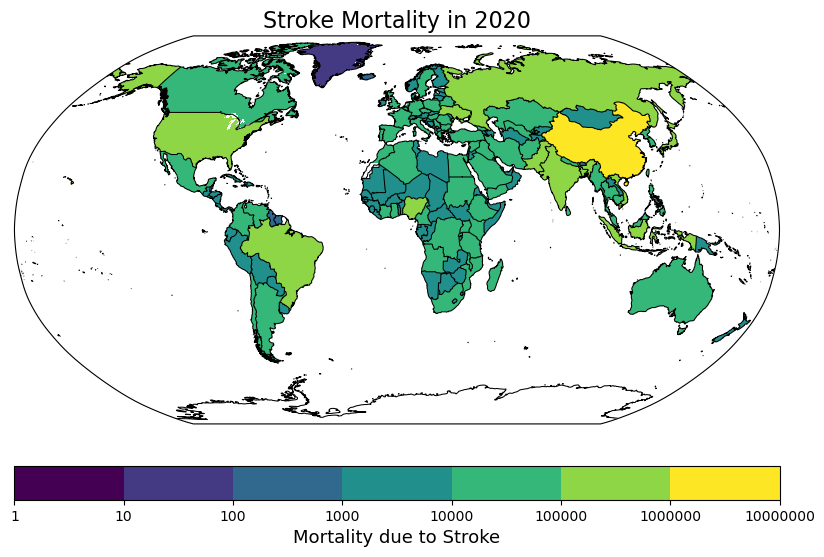

In [33]:
# === Main loop ===

for health_VAR in health_vars:
    for year in [2000, 2010, 2020]:
        bmr_file = f"GBD_BMR_Country_{health_VAR}_newlabels_1990-2009.nc"
        bmr_path = os.path.join(BMR_DIR, bmr_file)
        bmr = xr.open_dataarray(bmr_path)

        # Select mean value of bmr
        bmr_mean = bmr.sel(quantile="mean")

        pop_file = "ssp2_country_level_2000-2100.nc"
        pop_path = os.path.join(POP_DIR, pop_file)
        pop = xr.open_dataarray(pop_path)

        # Select year for population
        pop_year = pop.sel(year=year)

        mortality = (bmr_mean/100000) * pop_year

        global_map_mortality = create_global_country_map(mortality)

        plot_log_mortality(
            land_filter(global_map_mortality),
            health_VAR,
            year,
            SAVE_DIR)